# Joint Recurrence Plots Analysis - Generalized Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [1]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
import string
from tqdm import tqdm

from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform, cdist

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

Define functions to compute recurrence plots using Fixed Amount of Neighbors (FAN).

In [2]:
#Recurrence matrix updated version
def recurrence_matrix_fan(timeseries, RR, transpose = False):
    nn_i = int(RR*len(timeseries))

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)

            current_row = np.array(current_row)
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        for i in range(d_matrix.shape[0]):
            current_row = d_matrix[i]
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1

            d_matrix[i] = current_row   

        return d_matrix 

In [3]:
#Import models
nosynch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/GS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/GS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/GS_synch1.csv').to_numpy()

synch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/GS_synch2.csv').to_numpy()

In [4]:
#View the individual recurrence plots
#No synch
rm_nosynch1 = recurrence_matrix_fan(nosynch1, RR = 0.1)

rm_nosynch2 = recurrence_matrix_fan(nosynch2, RR = 0.1)

#Synch
rm_synch1 = recurrence_matrix_fan(synch1, RR = 0.1)

rm_synch2 = recurrence_matrix_fan(synch2, RR = 0.1)

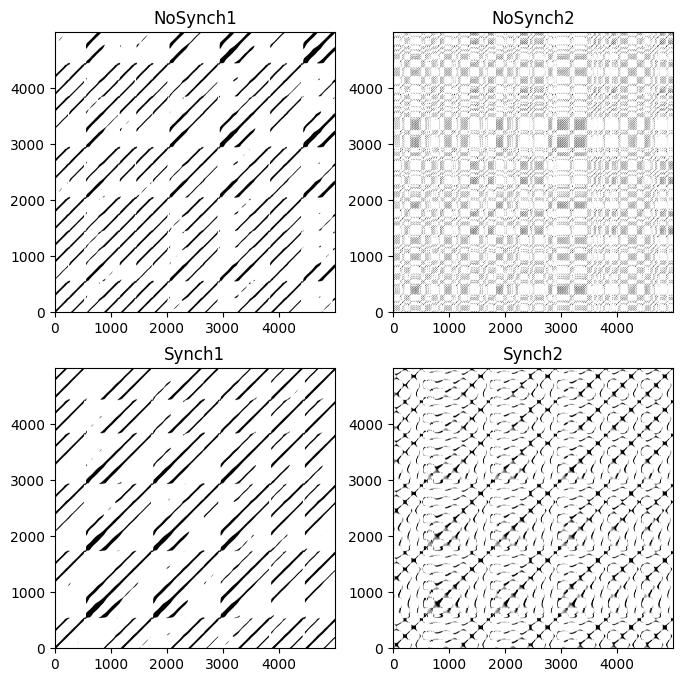

In [5]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

In [6]:
#Compute JRPs
#No synch
RMat_LS_nosynch = rm_nosynch1*rm_nosynch2

#Synch
RMat_LS_synch = rm_synch1*rm_synch2

In [7]:
#Manually compute a lagged time series for the calculation of S(tau)
lagged_time_series_y = [synch2[i:len(synch1)-100+i] for i in range(100)]

In [8]:
#Define a the time series to compare against the lagged ones
rec_x = recurrence_matrix_fan(synch1[:-100], RR=0.1)

In [9]:
#Check the recurrence rate of both JRPs
print(np.sum(RMat_LS_nosynch/(5000**2)), np.sum(RMat_LS_synch/(5000**2)))

0.01324808 0.044970559999999986


In [10]:
#Calculate S(tau) and find its maximum value
s_tau_synch = []

for i in range(100):
    actual_y = lagged_time_series_y[i]
    

    rec_y = recurrence_matrix_fan(actual_y, RR=0.1)

    jrp = rec_x*rec_y

    N = len(actual_y)


    s_tau_synch.append((np.sum(jrp)/(N**2))/0.1)

In [11]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_time_series_y[max_lag]

RMat_max_JRP_tau  = recurrence_matrix_fan(max_JRP_tau,RR=0.1)

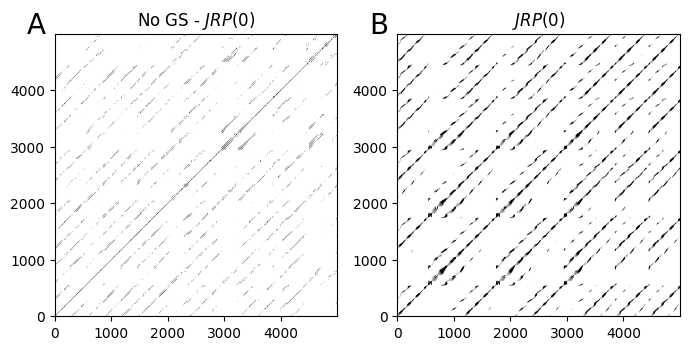

In [12]:
#Visualize JRPs
fig, axs = plt.subplots(1,2,figsize=(7, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No GS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
#fig.savefig('plots/JRPs_GS2FNN.pdf', dpi=300)

In [17]:
#Model to compute the GS system
def coupled_system(t, state, driver="roessler", response="lorenz", 
                   a=0.2, b=0.2, c=5.7,
                   sigma=10, rho=28, beta=8/3, eps=0.1,
                   synch=["x", "y", "z"],
                   g=None):
    '''
    g : Functional Relationship between driver and response system (python function)
    '''

    if g is None:
          def g(x):
                return x

    x1, y1, z1, x2, y2, z2 = state

    if driver == "roessler":
        dx1 = -(y1 + z1)
        dy1 = x1 + a * y1
        dz1 = b + (x1 - c) * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2) 
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2
    
    elif driver == "lorenz":
        dx1 = sigma * (y1 - x1)
        dy1 = x1 * (rho - z1) - y1
        dz1 = x1 * y1 - beta * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2)
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2


    return [dx1, dy1, dz1, dx2, dy2, dz2]

In [18]:
T = 12000 * 0.02
dt = 0.02

XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.16, 0.1, 8.5        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz

driver = "roessler"
response = "lorenz"

synch = ["x"] 

def g(x):
      #return np.tanh(x)
      return x

In [19]:
#### Integration ####

epss = np.linspace(0,150,50)
#epss = np.arange(0, 150, 3) 

results = {}

for e in tqdm(epss):
    results[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),
        method="RK45"
    )

100%|██████████| 50/50 [00:27<00:00,  1.82it/s]


The code block below was used to compute the JPR values for the different coupling values. Due to the time it took to compute, we import directly the result and leave the code inside quotation marks.

In [20]:
'''
JPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    ref = recurrence_matrix_fan(sol1[:-100],RR=0.1)

    lagged_JR_synch_i = [ref*recurrence_matrix_fan(sol2[j:len(sol2)-100+j],RR=0.1) for j in range(40)]
    
    s_tau_synch_i = np.array([(np.sum(lagged_JR_synch_i[k])/(len(sol1[:-100])**2))/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)

'''

'\nJPR_list = []\n\nfor e in tqdm(epss):\n    sol_c = results[e]\n\n    sol1 = sol_c.y[0:3, 7000:].T\n    sol2 = sol_c.y[3:6, 7000:].T\n\n    ref = recurrence_matrix_fan(sol1[:-100],RR=0.1)\n\n    lagged_JR_synch_i = [ref*recurrence_matrix_fan(sol2[j:len(sol2)-100+j],RR=0.1) for j in range(40)]\n    \n    s_tau_synch_i = np.array([(np.sum(lagged_JR_synch_i[k])/(len(sol1[:-100])**2))/0.1 for k in range(len(lagged_JR_synch_i))])\n\n\n    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)\n\n    JPR_list.append(JPR_i)\n\n'

In [21]:
'''
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("GS_JPR_listFAN.csv", index=False)
'''

'\n#Save to avoid computing it again\nJPR_list_saved = pd.DataFrame(JPR_list)\n\n# save the dataframe as a csv file\nJPR_list_saved.to_csv("GS_JPR_listFAN.csv", index=False)\n'

In [22]:
#Import models
JPR_list = pd.read_csv('GS_JPR_listFAN.csv').to_numpy()

In [23]:
CPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    RP_drive = recurrence_matrix_fan(sol1,RR=0.1)
    RP_response = recurrence_matrix_fan(sol2,RR=0.1)

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

100%|██████████| 50/50 [01:34<00:00,  1.90s/it]


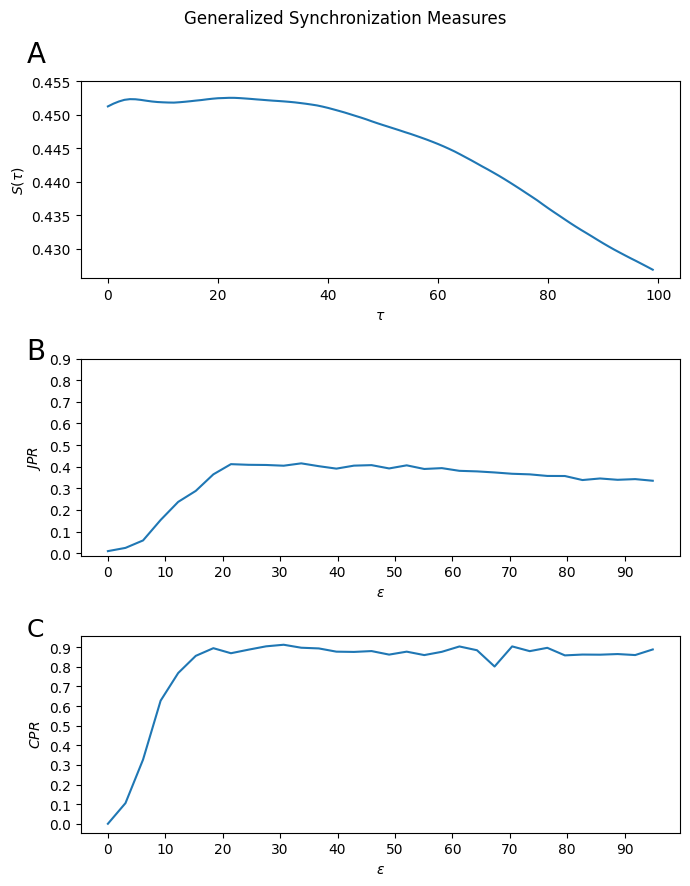

In [ ]:
'''
#Plot GS Measures
fig, axs = plt.subplots(3,1,figsize=(7, 9))

#S tau
axs[0].plot(s_tau_synch)
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$S(\tau)$')
axs[0].set_yticks(np.arange(0.43,0.455,0.005))
#axs[0].axvline(max_lag, ls = '--', color = 'gray')
axs[0].text(-0.09, 1.1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

#JPR
axs[1].set_ylabel(r"$JPR$")
axs[1].set_xlabel(r"$\epsilon$")
axs[1].text(-0.09, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
axs[1].plot(epss[:-18],JPR_list[:-18])
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,100,10))



#CPR
axs[2].set_xlabel(r"$\epsilon$")
axs[2].text(-0.09, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=18)
axs[2].plot(epss[:-18],CPR_list[:-18])
axs[2].set_yticks(np.arange(0,1,0.1))
axs[2].set_xticks(np.arange(0,100,10))
axs[2].set_ylabel(r"$CPR$")


fig.suptitle('Generalized Synchronization Measures')

plt.tight_layout()
plt.show()


#fig.savefig('plots/GS_JPRandCPRFAN.pdf', dpi=300)
'''

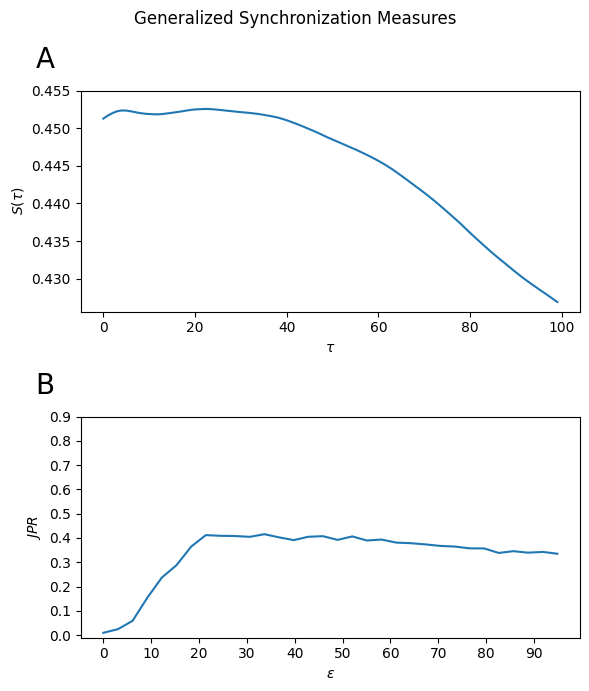

In [26]:
#Plot GS Measures
fig, axs = plt.subplots(2,1,figsize=(6, 7))

#S tau
axs[0].plot(s_tau_synch)
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$S(\tau)$')
axs[0].set_yticks(np.arange(0.43,0.455,0.005))
#axs[0].axvline(max_lag, ls = '--', color = 'gray')
axs[0].text(-0.09, 1.1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

#JPR
axs[1].set_ylabel(r"$JPR$")
axs[1].set_xlabel(r"$\epsilon$")
axs[1].text(-0.09, 1.1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
axs[1].plot(epss[:-18],JPR_list[:-18])
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,100,10))


fig.suptitle('Generalized Synchronization Measures')

plt.tight_layout()
plt.show()


fig.savefig('plots/GS_JPRandCPRFAN.pdf', dpi=300)